# PS-S6E01: Ridge Regression

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

Unlike XGBoost or LightGBM, Ridge is a linear model. It captures global trends and linear correlations (like `study_hours` vs `score`) that tree-based models might approximate with step functions. Blending this with tree models often reduces variance and improves the final score.  
This notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV, ElasticNetCV, HuberRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_experiment_setup import ExperimentSetup
from ps_s06e01_model_visualizer import ModelVisualizer

# Settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
helper = ExperimentSetup(model_name='Ridge')
seed = helper.set_seeds()
helper.configure_pandas()

TARGET = 'exam_score'

# Switch between 'Ridge', 'Huber', and 'Elasticnet'
LINEAR_MODEL = 'Elasticnet'

# Logit-encode target variable
ENCODE_TARGET = False

Random seed set to: 10301


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering Strategy

We employ a custom `FeatureFactory` to inject domain-specific biases into the dataset. We use a specific set of strategies for the Linear Model:


* **Log/Polynomials:** To help the linear model capture non-linear relationships.
* **One-Hot Encoding:** Essential for linear models.
* **Gaussian Transform:** Puts features on the same scale.

In [5]:
# Strategies specifically chosen for a Linear Model
fe_strategies = [
    'drop_id',
    'manual_formula',    # Domain knowledge formula
    'ordinal_encoding',  # Target Encoding
    'binning',           # Aggressive Binning
    'one_hot_encoding',  # One-Hot Encode the BINS and low-cardinality cats
    'standard_scaling'   # Use Standard Scaling
]


In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 44
     age  study_hours  class_attendance  sleep_hours  sleep_quality_ord  \
0  0.201        1.656             1.538       -1.245                  1   
1 -1.126        0.402             1.309       -1.360                  0   
2 -0.241        0.287             1.183       -0.729                  0   
3 -0.684       -0.848            -1.290        0.703                  1   
4  1.086        1.546             0.856        1.448                  2   

   facility_rating_ord  exam_difficulty_ord  effort_gap  manual_formula  \
0                    0                    0      -1.656           1.281   
1                    1                    1      -0.402           0.085   
2                    2                    1      -0.287           0.824   
3                    2                    1       0.848          -0.871   
4                    2                    0      -1.546           2.023   

   gender_fema

## Model Training

`BayesianRidge` auto-tunes regularization.

In [7]:
n_folds = 5

# Create 10 bins for stratification (0-10, 10-20... 90-100)
# This allows us to balance the "grade distribution" across folds
y_stratified = pd.cut(y, bins=10, labels=False)

kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Update the split call to include the stratified label
oof_preds = np.zeros(len(X_full))
test_preds = np.zeros(len(X_test))
scores = []

print(f'Starting {LINEAR_MODEL} Training with {n_folds} folds...')

split_iter = kf.split(training_df, y_stratified)
for fold, (train_idx, val_idx) in enumerate(split_iter):
    X_train_fold = training_df.iloc[train_idx]
    X_val_fold = training_df.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans = fe.transform(X_val_fold)
    X_test_trans = fe.transform(test_df)

    y_train_trans = y_train_fold
    if ENCODE_TARGET:
        # Target Transformation (QuantileTransformer)
        # This forces the target into a Normal Distribution, which Linear Models love.
        y_qt = QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(len(y_train_fold), 1000),
            random_state=seed
        )
        y_train_trans = y_qt.fit_transform(y_train_fold.values.reshape(-1, 1)).ravel()
        
    if LINEAR_MODEL == 'Ridge':
        alphas = np.logspace(-6, 3, 200)
        model = RidgeCV(
            alphas=alphas,
            scoring='neg_root_mean_squared_error'
        )
    elif LINEAR_MODEL == 'Huber':
        # Train Huber Regressor
        # epsilon=1.35 means errors smaller than 1.35 sigma are squared (MSE), 
        # larger errors are linear (MAE). This ignores outliers.
        model = HuberRegressor(
            epsilon=1.35, 
            max_iter=2000, 
            alpha=0.0001, # L2 regularization strength
            fit_intercept=True
        )
    elif LINEAR_MODEL == 'Elasticnet':
        alphas = np.logspace(-6, 2, 100)
        # l1_ratio grid: 0 -> Ridge-like, 1 -> Lasso-like
        model = ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
            alphas=alphas,
            cv=5,
            random_state=seed,
            max_iter=5000,
            n_jobs=-1
        )
    else:
        raise ValueError(f'Unknown LINEAR_MODEL: {LINEAR_MODEL}')

    model.fit(X_train_trans, y_train_trans)
    
    # Validation Predictions
    val_preds = model.predict(X_val_trans)
    if ENCODE_TARGET:
        val_preds = y_qt.inverse_transform(val_preds.reshape(-1, 1)).ravel()
    val_preds = np.clip(val_preds, 0, 100)
    oof_preds[val_idx] = val_preds
    
    # Test Predictions
    fold_test_preds = model.predict(X_test_trans)
    if ENCODE_TARGET:
        fold_test_preds = y_qt.inverse_transform(fold_test_preds.reshape(-1, 1)).ravel()
    fold_test_preds = np.clip(fold_test_preds, 0, 100)
    test_preds += fold_test_preds / n_folds
    
    # Metrics
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
    scores.append(fold_rmse)

    if LINEAR_MODEL == 'Ridge':
        alpha_info = f'alpha={model.alpha_}'
    elif LINEAR_MODEL == 'Huber':
        alpha_info = f'alpha={model.alpha}'
    else:
        alpha_info = f'alpha={model.alpha_:.3g}, l1_ratio={model.l1_ratio_}'

    print(f'Fold {fold+1} RMSE: {fold_rmse:.5f} | {alpha_info}')

print(f'\nOOF RMSE: {np.mean(scores):.5f} ± {np.std(scores):.5f}')


Starting Elasticnet Training with 5 folds...
Fold 1 RMSE: 8.89292 | alpha=0.00359, l1_ratio=1.0
Fold 2 RMSE: 8.88400 | alpha=0.00433, l1_ratio=1.0
Fold 3 RMSE: 8.88416 | alpha=0.00206, l1_ratio=0.99
Fold 4 RMSE: 8.90529 | alpha=0.00359, l1_ratio=0.9
Fold 5 RMSE: 8.87551 | alpha=0.00359, l1_ratio=0.95

OOF RMSE: 8.88838 ± 0.01009


## Evaluation

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features make sense (e.g., `study_hours` or `class_attendance` should likely be high).
* **Sanity Check:** If `id` or a random noise column appears in the top 5, there is a data leakage problem.
* **Engineering Check:** Look for the engineered features (e.g., `restoration_index`, `interaction_score`). If they appear near the top, the feature engineering added real value.

Top 5 Features raising score (+):
manual_formula          14.618
class_attendance         0.482
facility_rating_ord      0.306
study_method_coaching    0.295
sleep_quality_ord        0.151
dtype: float64

Top 5 Features lowering score (-):
effort_gap                   -1.587
study_hours_class_0          -0.274
sleep_quality_poor           -0.220
study_method_self-study      -0.095
study_method_online videos   -0.089
dtype: float64


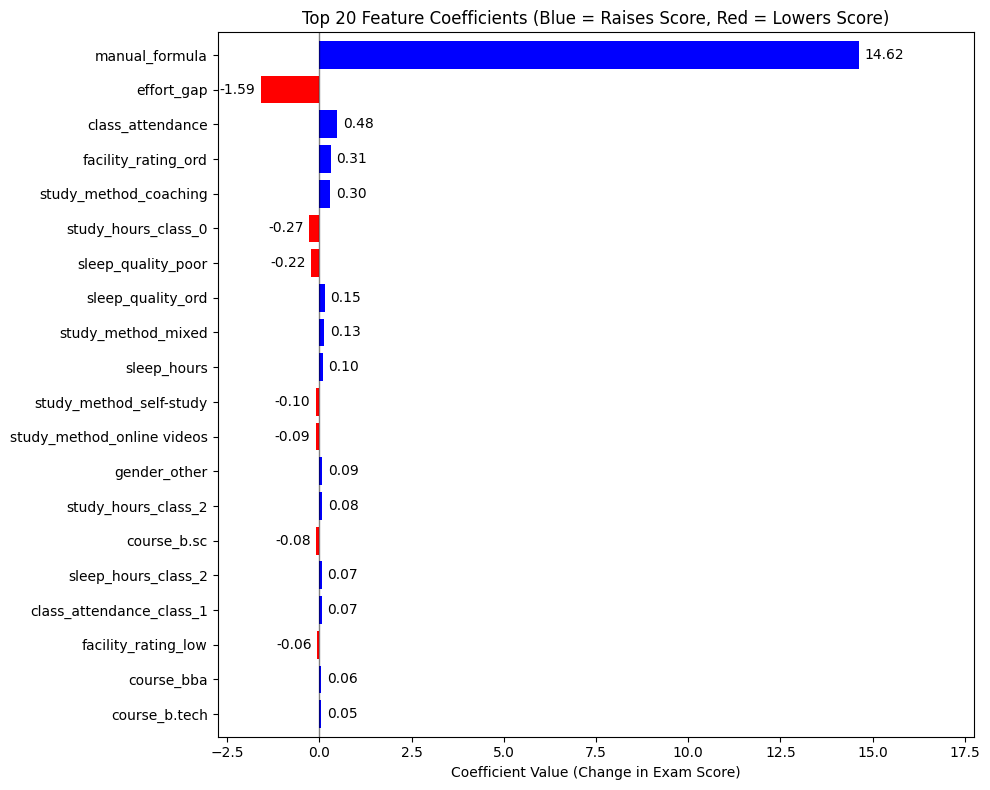

In [8]:
# Extract coefficients from the fitted model
coefs = pd.Series(model.coef_, index=X_full.columns)

# Sort by 'Importance' (Absolute Value)
# We care about the magnitude, whether it pushes the score up (+) or down (-
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

# Print Top 10 Positive and Negative Drivers
print('Top 5 Features raising score (+):')
print(coefs.sort_values(ascending=False).head(5))
print('\nTop 5 Features lowering score (-):')
print(coefs.sort_values(ascending=True).head(5))

# Plot the Top 20 most impactful features
plt.figure(figsize=(10, 8))
top_20 = coefs_sorted.head(20)

# Color bars: Blue for Positive, Red for Negative
colors = ['blue' if x > 0 else 'red' for x in top_20]

ax = top_20.plot(kind='barh', color=colors, width=0.8)

plt.title('Top 20 Feature Coefficients (Blue = Raises Score, Red = Lowers Score)')
plt.xlabel('Coefficient Value (Change in Exam Score)')
plt.axvline(x=0, color='black', linewidth=1, alpha=0.5)

# Add Value Labels
# We loop through containers (though there is only one at this time)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=10)
    
plt.gca().invert_yaxis() # Put the most important at the top

# Add a little extra space on the x-axis so labels don't get cut off
xmin, xmax = plt.xlim()
plt.xlim(xmin * 1.15, xmax * 1.15) 

plt.tight_layout()
plt.show()

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

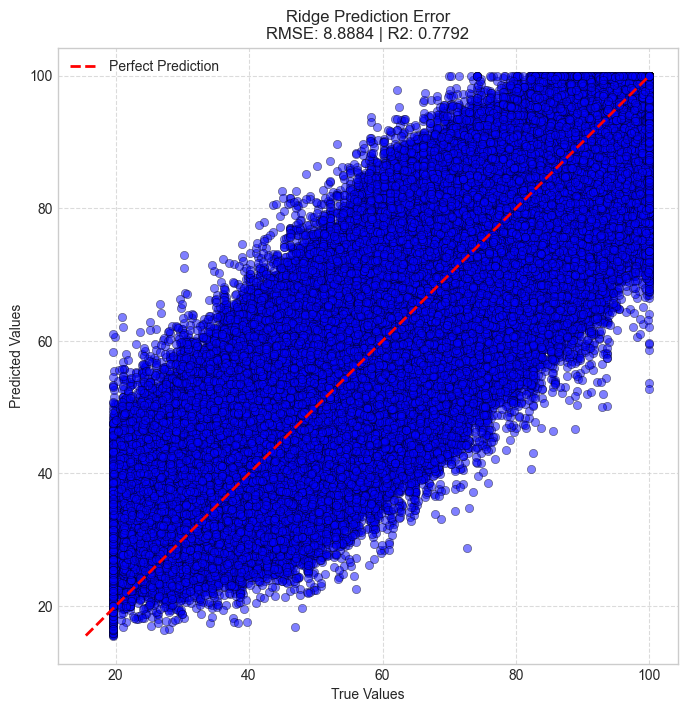

In [9]:
mviz = ModelVisualizer(model_name='Ridge')

mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

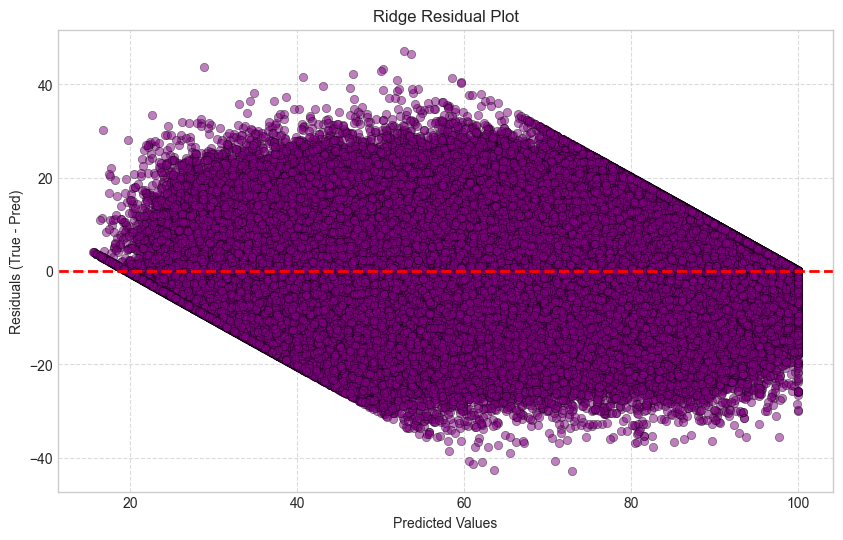

In [10]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [11]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.844
1  630001      69.535
2  630002      87.390
3  630003      55.222
4  630004      47.709
5  630005      71.439
6  630006      73.068
7  630007      58.362
8  630008      78.949
9  630009      92.338


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [12]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# 1. Submission File (for direct upload)
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds
submission_df.to_csv('submission.csv', index=False)

# 2. OOF Predictions (for Blending)
oof_df = pd.DataFrame({'id': training_df.index, 'pred_ridge': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/ridge_oof_preds.csv', index=False)

# 3. Test Predictions (for Blending)
test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_ridge': test_preds})
test_pred_df.to_csv(f'{output_dir}/ridge_test_preds.csv', index=False)

print(f'Saved files to {output_dir}/: ridge_oof_preds.csv, ridge_test_preds.csv')

Saved files to predictions/: ridge_oof_preds.csv, ridge_test_preds.csv
